# Data Preprocessing
Antes de poder extraer insights confiables y modelos complejos, los datos deben ser TRABAJADOS, preparados, corregidos y estructurados.

Estas etapas garantizan datos de calidad, coherencia y utiles.

1. Data Gathering and Exploration
2. Data Integration
3. Data Cleaning

1. **Data Gathering**

Recolectar e importar los datos desde su fuente.

(github y seaborn tienen el dataset titanic, listo como DataFrame, NO PUDE HACERLO desde Kaggle):



el JSON está correcto, la API funciona, pero Kaggle da error 401 al descargar la competencia Titanic ---> no tengo acceso a los datos de la competencia vía API, aunque esté logueada.

Kaggle a veces bloquea la descarga vía API si no “has aceptado la competencia”, y la UI actual de Titanic no muestra botón de aceptación (comprobado).

Existe una solución rápida y confiable sin pelear más con la API: descargar desde una fuente alternativa.

1. **Data Exploration**

Entender el dataset crudo: columnas, tipos de datos, valores faltantes y estructura general, si hay errores/inconsistencias. Permite detectar problemas temprano.

In [ ]:
# NO LOGRO HACER LA CONEXION CON EL KAGGLE....

#Plan B: descargar el CSV de otra fuente confiable

#1° OPCION:n GitHub

# === IMPORTAR LIBRERIAS ===
import pandas as pd

# === Data Gathering ===
# Dataset equivalente a Titanic original de Kaggle , con PassengerId
url_train = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# === LOAD THE DATA ===
train_df = pd.read_csv(url_train)

# Explore the dataset
shape = train_df.shape
print('Tamaño de la base es', shape)
print(train_df.head())
print(train_df.info())
print(train_df.columns)

Tamaño de la base es (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            3734

In [ ]:
#2° OPCION, directo desde Seaborn, sin PassengerId

# # === IMPORTAR LIBRERIAS ===
import seaborn as sns
import pandas as pd

# # === Data Gathering ===
# # === LOAD THE DATA ===
titanic_data = sns.load_dataset('titanic')

# Explore the dataset
shape = titanic_data.shape
print('Tamaño de la base es', shape)
print(titanic_data.head())
print(titanic_data.info())
print(titanic_data.columns)


Tamaño de la base es (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  ----- 

2. **Data Integration**

Combinación de datos de múltiples orígenes en un único dataset coherente, asegurando consistencia en formatos, variables y estructuras.

- Uso de claves en común.

- Enriquece el análisis agregando contexto adicional (x ej datos demógraficos)

- segun los parametros necesarios, hay diferentes tipos de join (left, right, inner, outer); consecuentemente, distintos datos se conservan al fusionar los conjuntos.

In [ ]:
# --- 2️⃣ Crear un CSV hipotético 'passenger_demographics.csv' , con 10 pasajeros con datos de país y "grupo etario" (de mentirita)
passenger_demo_data = pd.DataFrame({
    'PassengerId': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],  # IDs coincidentens con Titanic
    'Country': ['UK', 'USA', 'France', 'Germany', 'Italy', 'UK', 'USA', 'France', 'Germany', 'Italy'],
    'AgeGroup': ['Adult', 'Adult', 'Adult', 'Adult', 'Adult', 'Child', 'Adult', 'Child', 'Adult', 'Child']
})

# --- 3️⃣ Guardarlo como CSV temporal (para usar luegopd.read_csv) ---
passenger_demo_data.to_csv('passenger_demographics.csv', index=False)

# --- 4️⃣ Leer y cargar el adicional CSV hipotético ---
passenger_demographics = pd.read_csv('passenger_demographics.csv')

# --- 5️⃣ Merge con train_df: Perform data integration (on a common key) ---
integrated_data = pd.merge(train_df, passenger_demographics, on='PassengerId', how='left')

# --- 6️⃣ Mostrar resultado: Explore the integrated dataset ---
print(integrated_data.head(15))



    PassengerId  Survived  Pclass  \
0             1         0       3   
1             2         1       1   
2             3         1       3   
3             4         1       1   
4             5         0       3   
5             6         0       3   
6             7         0       1   
7             8         0       3   
8             9         1       3   
9            10         1       2   
10           11         1       3   
11           12         1       1   
12           13         0       3   
13           14         0       3   
14           15         0       3   

                                                 Name     Sex   Age  SibSp  \
0                             Braund, Mr. Owen Harris    male  22.0      1   
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                              Heikkinen, Miss. Laina  female  26.0      0   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                

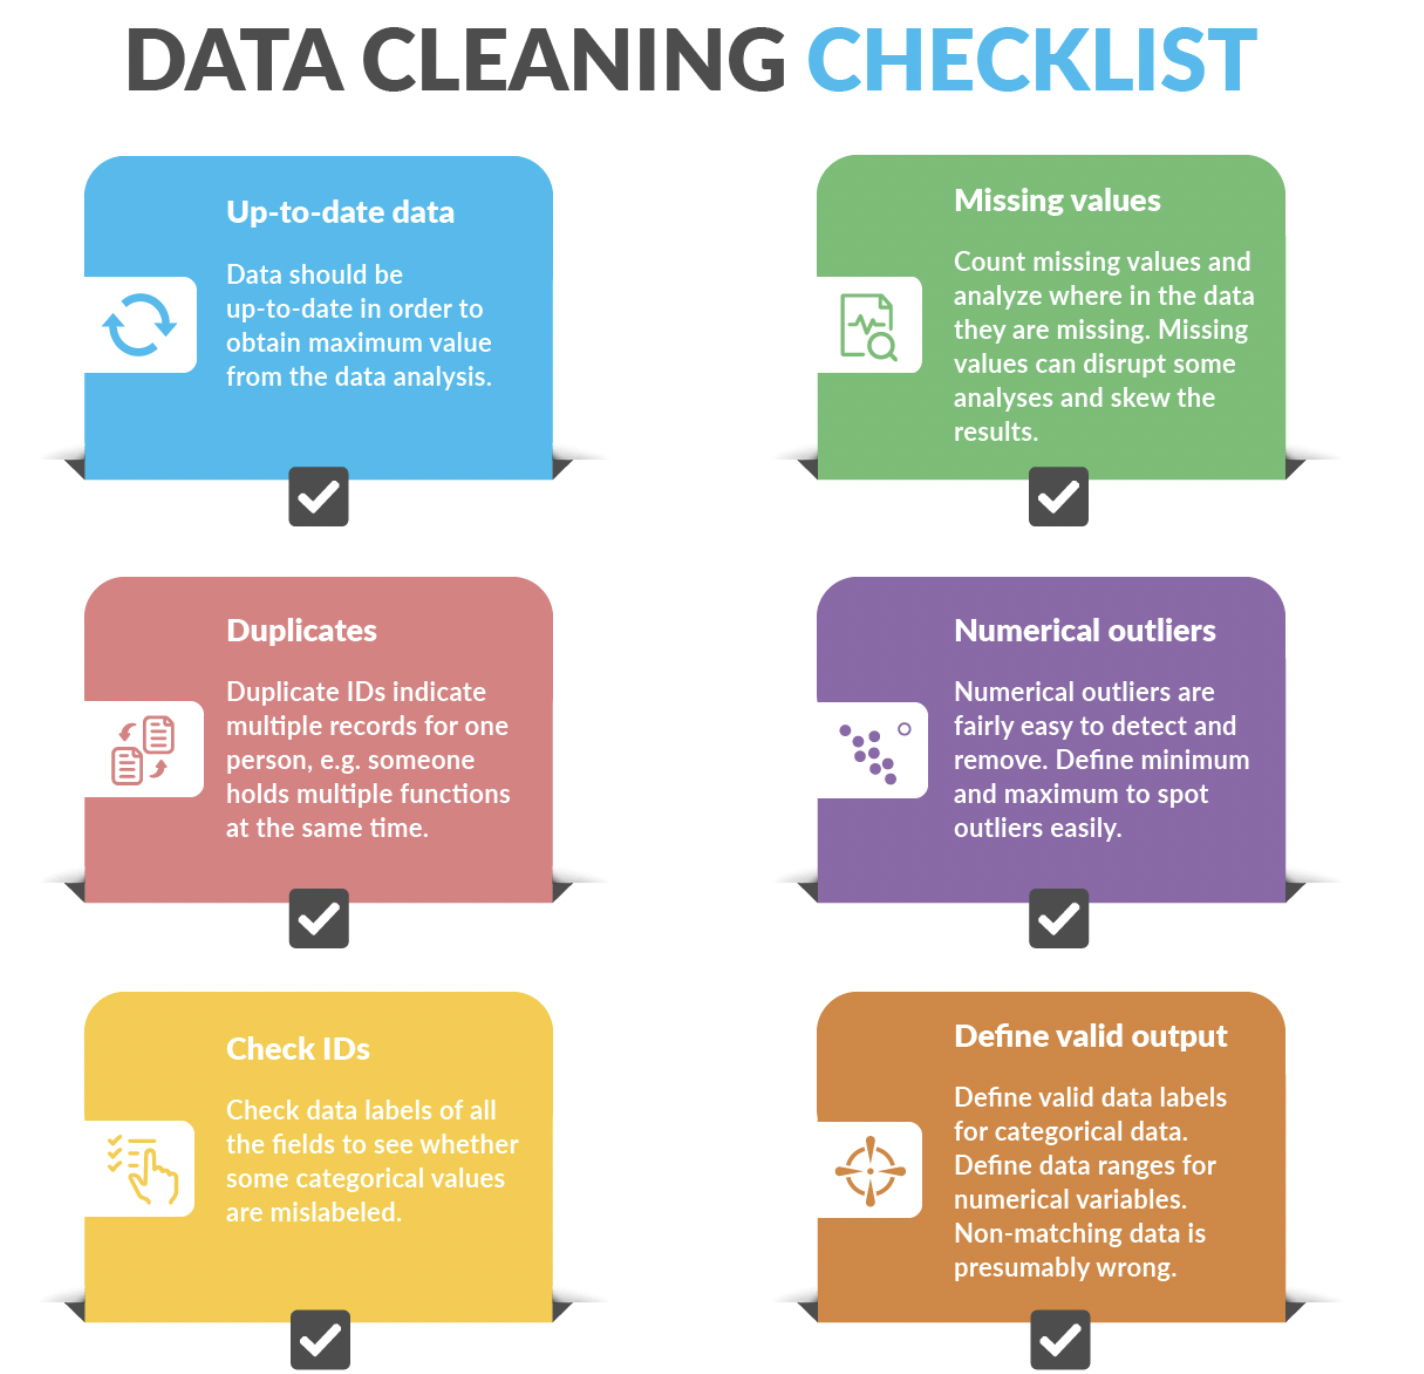

3. **Data Cleaning**
Eliminar errores y mejorar la consistencia del dataset mediante tareas clave:

* Eliminación de duplicados.
Evita distorsionar resultados estadísticos y modelos. drop_duplicates():

* Eliminación de datos irrelevantes.
Se descartan columnas que no aportan valor al análisis. drop function

* Corrección de errores estructurales.
Ajuste de formatos incorrectos, como conversion de fechas a datetime format.

* Identificación de valores faltantes.
Usando funciones como isnull() para evaluar su impacto.

* Análisis de outliers (es cleaning o es transformacion??)

In [ ]:
# Remove duplicate rows
train_df = train_df.drop_duplicates()

# Verify duplicates are removed
print(train_df.duplicated().sum())

# Remove irrelevant columns (e.g., 'Cabin' and 'Ticket')
train_df = train_df.drop(['Cabin', 'Ticket'], axis=1)

# Fixing Structural Errors
#Convert 'Date' column to datetime format
#train_df['Date'] = pd.to_datetime(train_df['Date'])

0


# Manejo de valores faltantes - 3 estrategias:

- Eliminar datos faltantes.
Adecuado cuando la pérdida de información es mínima y los faltantes **no están concentrados en columnas críticas**.

- Imputación.
Se rellenan valores faltantes usando constantes, medias, medianas o modas, cuando se quiere conservar la mayor cantidad de datos posible.

- Técnicas avanzadas.
Métodos como KNN o modelos predictivos se usan cuando las relaciones entre variables son complejas.

In [ ]:
#identificacion
import pandas as pd

# Check for missing values in a DataFrame
missing_data = train_df.isnull()
print(missing_data.head())

# Count missing values in each column
missing_counts = train_df.isnull().sum()
print(missing_counts)

   PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch   Fare  \
0        False     False   False  False  False  False  False  False  False   
1        False     False   False  False  False  False  False  False  False   
2        False     False   False  False  False  False  False  False  False   
3        False     False   False  False  False  False  False  False  False   
4        False     False   False  False  False  False  False  False  False   

   Embarked  
0     False  
1     False  
2     False  
3     False  
4     False  
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64


In [ ]:
#remover --> no son columnas relevantes

# Remove rows with missing values
df_cleaned = df.dropna()

# Remove columns with missing values
df_cleaned = df.dropna(axis=1)

NameError: name 'df' is not defined

In [ ]:
#imputacion --> se quiere conservar la mayor cantidad de datos posible.

# Fill missing values with a specific value (e.g., 0)
df_filled = df.fillna(0)

# Fill missing values with the mean of the column
df_filled = df.fillna(df.mean())

In [ ]:
# Técnicas avanzadas

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=2)
df_imputed = imputer.fit_transform(df)

# Manejo de Outliers

Los outliers son valores extremos que pueden sesgar análisis y modelos. Se eliminan o analizan según el contexto.

Se identifican si caen fuera del 1,5 x IQR (Interquartile Range):

Q1: percentil 25

Q3: percentil 75

IQR = Q3 − Q1

Se definen límites inferior y superior para detectar valores atípicos.

In [ ]:
# Identify and handle outliers in 'Fare' column
Q1 = train_df['Fare'].quantile(0.25)    #Calcular el primer cuartil (Q1)
Q3 = train_df['Fare'].quantile(0.75)    #Calcular el tercer cuartil (Q3)
IQR = Q3 - Q1                           #Calcular el rango intercuartílico (IQR)
lower_bound = Q1 - 1.5 * IQR            #Definir límites (bigotes) para boxplot
upper_bound = Q3 + 1.5 * IQR

#Filtrar los outliers
#Mantiene solo las filas donde Fare está entre lower_bound y upper_bound.
#Esto recorta los valores extremos para análisis más limpio.
train_df = train_df[(train_df['Fare'] >= lower_bound) & (train_df['Fare'] <= upper_bound)]

# --- ES MEJOR antes crear columna indicando si es outlier ---
#train_df['Age_Outlier'] = train_df['Fare'].apply(
#    lambda x: 'Outlier' if (x < lower_bound) or (x > upper_bound) else 'Normal'

print(f"{lower_bound:.2f}")
print(f"{upper_bound:.2f}")
train_df.nlargest(20, 'Fare')   #ya confirmo que los cortó
train_df.nsmallest(20, 'Fare')

-16.526999999999997
48.5562


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,0.0000,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,0.0000,S
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,0.0000,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,0.0000,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,0.0000,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,0.0000,S
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,0.0000,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,0.0000,S
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,0.0000,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,0.0000,S


🚀 Challenge: Outliers

1. Calculate the first quartile (Q1) and the third quartile (Q3) for the Age column in the Titanic dataset.

2. Compute the interquartile range (IQR) for the Age column.

3. Define the lower bound and upper bound for potential outliers based on the IQR.

4. Identify and count the number of outliers in the Age column if there is.

In [ ]:
# --- 2️⃣ Calcular Q1 y Q3 para Age ---
Q1 = train_df['Age'].quantile(0.25)
Q3 = train_df['Age'].quantile(0.75)

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")

# --- 3️⃣ Calcular IQR ---
IQR = Q3 - Q1
print(f"IQR: {IQR}")

# --- 4️⃣ Definir límites para posibles outliers ---
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# --- 5️⃣ Crear columna indicando si es outlier ---
train_df['Age_Outlier'] = train_df['Age'].apply(
    lambda x: 'Outlier' if (x < lower_bound) or (x > upper_bound) else 'Normal'
)

# --- 6️⃣ Contar cuántos outliers hay ---
outlier_count = (train_df['Age_Outlier'] == 'Outlier').sum()
print(f"Number of Age outliers: {outlier_count}")

# --- 7️⃣ Mostrar algunas filas con outliers ---
print(train_df[train_df['Age_Outlier'] == 'Outlier'][['PassengerId', 'Age', 'Age_Outlier']].head(15))



Q1: 19.0
Q3: 36.0
IQR: 17.0
Lower Bound: -6.5
Upper Bound: 61.5
Number of Age outliers: 13
     PassengerId   Age Age_Outlier
33            34  66.0     Outlier
96            97  71.0     Outlier
116          117  70.5     Outlier
252          253  62.0     Outlier
280          281  65.0     Outlier
456          457  65.0     Outlier
483          484  63.0     Outlier
545          546  64.0     Outlier
555          556  62.0     Outlier
570          571  62.0     Outlier
630          631  80.0     Outlier
672          673  70.0     Outlier
851          852  74.0     Outlier


# Data Transformation

1. **Data Normalization (Normalización de Datos)**

Es reescalar los datos a una misma escala, para que tengan un rango estándar y comparable, normalmente entre 0 y 1.

Sirve cuando las columnas tienen escalas muy distintas y quieres usarlas juntas.

✅ Propósito: que los valores estén en una escala comparable, especialmente útil para algoritmos sensibles a magnitudes (p.ej., KNN, redes neuronales, machine learning).

--> Si Age va de 1 a 80 y Fare va de 0 a 500, sin normalización Fare domina cualquier cálculo de distancia o correlación.

In [ ]:
# Cómo se hace
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
titanic_data['Age_normalized'] = scaler.fit_transform(titanic_data[['Age']])

# fit_transform → ajusta el rango mínimo y máximo de Age y transforma todos los valores.
# Resultado: Age_normalized va de 0 (mínimo) a 1 (máximo).
# Edad se sustituirá por Edad_normalizada

**2. Data Reduction (Reducción de Datos)**

Reducir la cantidad de información sin perder lo importante/relevante, producir resultados analíticos iguales o similares.

Muy útil para datasets grandes o de alta dimensión.

🔹 Técnica común: PCA (Principal Component Analysis):  transforma un conjunto de variables posiblemente correlacionadas en un conjunto menor de variables no correlacionadas llamadas componentes principales.

Conserva la mayor parte de la varianza de los datos.

✅ Propósito: simplificar datos, visualización o acelerar modelos, manteniendo la esencia de los datos.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)  # Queremos 2 dimensiones
reduced_data = pca.fit_transform(original_data)   # dataset 2D, que mantiene la información más importante de original_data.

**3. Data Aggregation (Agregación de Datos)**
Es combinar varios datos en uno solo, para resumir o simplificar análisis.

Agrupación y resumen de datos en distintos niveles para identificar patrones, tendencias

Muy usado en reportes, estadísticas o dashboards.

Ejemplo :  Datos de ventas diarios → sumarlos por mes → análisis mensual.

In [ ]:
monthly_sales = sales_data.groupby(pd.Grouper(freq='M')).sum()

In [ ]:
# 🚀 Challenge : Short-term Daily Precipitation Forecasting

# === IMPORTAR LIBRERIAS ===
import pandas as pd

# === Data Gathering ===
#Descargar el ZIP desde GitHub
!wget "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/Weather%20Dataset.zip" -O weather_dataset.zip

#Descomprimir el ZIP
!unzip -o weather_dataset.zip

#Ver qué archivos se extrajeron
!ls *.csv

#Cargar un CSV con pandas
weather_df = pd.read_csv('Weather Dataset/weatherHistory.csv')

# Explore the dataset
shape = weather_df.shape
print('Tamaño de la base es', shape)
print (weather_df.head())
print(weather_df.info())

--2026-02-09 14:55:04--  https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/Weather%20Dataset.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-DA-Bootcamp-2-/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20%26%20T/Weather%20Dataset.zip [following]
--2026-02-09 14:55:05--  https://media.githubusercontent.com/media/devtlv/Datasets-DA-Bootcamp-2-/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20%26%20T/Weather%20Dataset.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.10

Descripción del dataset:  dataset meteorológico diario, 2006-2016.

Tamaño (96453 filas, 12 columnas)

Estructura del dataset

Formatted Date --> Fecha y hora del registro. Se puede convertir a datetime para agrupar por día, mes, año, etc.

Summary --> Texto resumen del clima (ej: "Light Rain", "Clear"). Útil para categorización rápida.

Precip --> Tipo de precipitación: normalmente "rain" o "snow". Ideal para filtrar registros de lluvia.

Temperature (C) --> Temperatura en grados Celsius.

Apparent Temperature (C) --> Sensación térmica en °C.

Humidity --> Humedad relativa (0-1).

Wind Speed (km/h) --> Velocidad del viento.

Wind Bearing (degrees) --> Dirección del viento en grados.

Visibility (km) --> Visibilidad en kilómetros.

Loud Cover --> nublado, valores 0–1.

Pressure (millibars) --> Presión atmosférica.

Daily --> Texto resumen diario del clima.

- - - - - - -

**FALTARIA ALGUN INDICIO DE UBICACION Y LOS MM PRECIPITADOS**

In [ ]:
# Data Normalization
# 1. Perform Min-Max normalization on the Temperature (C) values.
# 2. Create a new column, e.g., Temperature (C)_normalized to store the normalized values.

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# --- Crear el scaler ---
scaler = MinMaxScaler()

# --- Aplicar Min-Max normalization a 'Temperature (C)' ---
weather_df['Temperature (C)_normalized'] = scaler.fit_transform(weather_df[['Temperature (C)']])

# --- Verificar las primeras filas ---
weather_df[['Temperature (C)', 'Temperature (C)_normalized']].head(10)




,Temperature (C),Temperature (C)_normalized
0,9.472222,0.506975
1,9.355556,0.505085
2,9.377778,0.505445
3,8.288889,0.487805
4,8.755556,0.495365
5,9.222222,0.502925
6,7.733333,0.478805
7,8.772222,0.495635
8,10.822222,0.528845
9,13.772222,0.576636


In [ ]:
# Data Reduction
# 1. Apply Principal Component Analysis (PCA) to reduce the dimensionality of the dataset.
# 2. Reduce the dataset to a 2D representation using PCA.


import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1️⃣ Seleccionar columnas numéricas relevantes ---
numeric_cols = ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
                'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
                'Loud Cover', 'Pressure (millibars)']

numeric_data = weather_df[numeric_cols]

# --- 2️⃣ Escalar los datos (PCA funciona mejor con datos estandarizados) ---
# media 0 y desviación estándar 1
# Esto evita que columnas con rangos grandes dominen el PCA.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# --- 3️⃣ Aplicar PCA para reducir a 2 dimensiones ---
# → convierte 8 variables originales en 2 nuevas variables (PC1 y PC2) que capturan la mayor parte de la varianza.
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)

# --- 4️⃣ Crear un DataFrame con las 2 componentes principales ---
pca_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])

# --- Mostrar contribución de cada variable a PC1 y PC2 (loadings) ---
loadings = pd.DataFrame(pca.components_, columns=numeric_cols, index=['PC1', 'PC2'])
print("Contribución de cada variable a PC1 y PC2:")
print(loadings)

# --- 5️⃣ Verificar las primeras filas ---
print("\nPrimeras filas del dataset reducido (PC1 y PC2):")
print(pca_df.head(10))

Contribución de cada variable a PC1 y PC2:
     Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
PC1         0.569056                  0.560820 -0.479807           0.068234   
PC2        -0.133956                 -0.184472 -0.145540           0.770546   

     Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  
PC1                0.032337         0.354537         0.0              0.006612  
PC2                0.511824         0.119317         0.0             -0.238543  

Primeras filas del dataset reducido (PC1 y PC2):
        PC1       PC2
0 -0.193205  0.781919
1 -0.131097  0.861931
2 -0.282776 -0.637340
3 -0.186826  0.949487
4 -0.138043  0.536315
5 -0.197401  0.807552
6 -1.051036  0.466778
7 -0.771199  0.683242
8 -0.280327  0.310885
9  0.313485  0.523309


In [ ]:
# Data Aggregation
# 1. Group the data by date and calculate the average temperature for each year.
# 2. Group the data by date and calculate the average temperaturen for each month.
# 3. Create a new dataset with the aggregated values.



import pandas as pd

# --- 1️⃣ Cargar CSV ---
weather_df = pd.read_csv('Weather Dataset/weatherHistory.csv')

# --- 2️⃣ Crear columnas de año y mes usando solo string ---
weather_df['Year'] = weather_df['Formatted Date'].astype(str).str[:4]

def extract_month(date_str):
    try:
        date_str = str(date_str)
        if '-' in date_str:
            return int(date_str.split('-')[1])
        elif '/' in date_str:
            return int(date_str.split('/')[1])
        else:
            return None
    except:
        return None

weather_df['Month_Num'] = weather_df['Formatted Date'].apply(extract_month)

# Filtrar filas donde año o mes no pudieron extraerse
weather_df = weather_df[weather_df['Year'].notna() & weather_df['Month_Num'].notna()].copy()
weather_df['Year'] = weather_df['Year'].astype(int)

# --- 3️⃣ Promedio de temperatura por año ---
yearly_avg_temp = weather_df.groupby('Year')['Temperature (C)'].mean().reset_index()
yearly_avg_temp.rename(columns={'Temperature (C)': 'Avg_Temperature'}, inplace=True)

# --- 4️⃣ Promedio de temperatura por mes (todos los años acumulados) ---
monthly_avg_temp = weather_df.groupby('Month_Num')['Temperature (C)'].mean().reset_index()
monthly_avg_temp.rename(columns={'Temperature (C)': 'Avg_Temperature'}, inplace=True)

# Cambiar número de mes a nombre de mes
monthly_avg_temp['Month'] = monthly_avg_temp['Month_Num'].apply(
    lambda x: pd.Timestamp(month=int(x), day=1, year=2000).strftime('%B')
)
monthly_avg_temp = monthly_avg_temp[['Month', 'Avg_Temperature']]

# --- 5️⃣ Formatear temperaturas a 2 decimales ---
yearly_avg_temp['Avg_Temperature'] = yearly_avg_temp['Avg_Temperature'].round(2)
monthly_avg_temp['Avg_Temperature'] = monthly_avg_temp['Avg_Temperature'].round(2)

# --- 6️⃣ Guardar resultados en diccionario ---
aggregated_data = {
    'Yearly': yearly_avg_temp,
    'Monthly': monthly_avg_temp
}

# --- 7️⃣ Mostrar resultados ---
print("Promedio de temperatura por año (2 decimales):")
print(aggregated_data['Yearly'].head())

print("\nPromedio de temperatura por mes (acumulando todos los años, 2 decimales):")
print(aggregated_data['Monthly'])


Promedio de temperatura por año (2 decimales):
   Year  Avg_Temperature
0  2006            11.22
1  2007            12.14
2  2008            12.16
3  2009            12.27
4  2010            11.20

Promedio de temperatura por mes (acumulando todos los años, 2 decimales):
        Month  Avg_Temperature
0     January             0.81
1    February             2.16
2       March             6.91
3       April            12.76
4         May            16.87
5        June            20.72
6        July            22.96
7      August            22.35
8   September            17.52
9     October            11.34
10   November             6.59
11   December             1.63


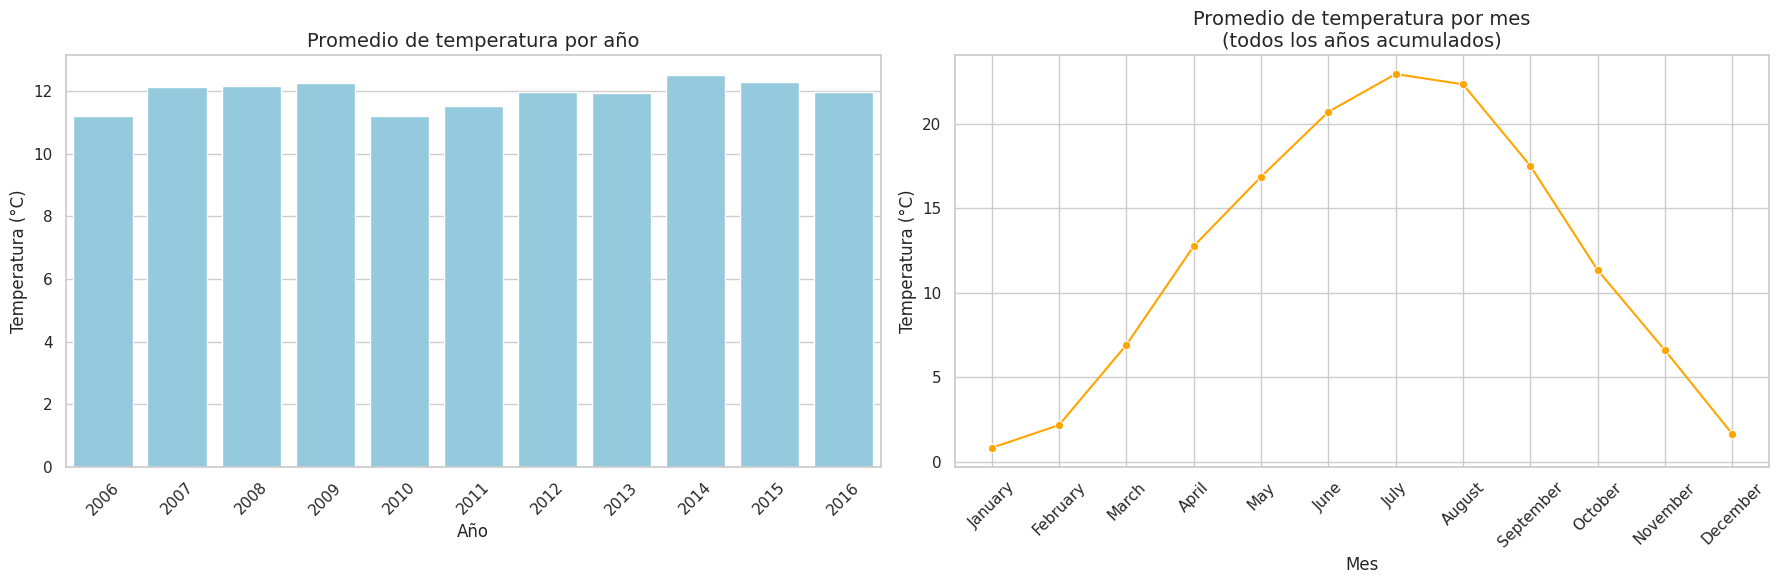

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configurar estilo ---
sns.set(style="whitegrid")

# --- Datos ---
yearly = aggregated_data['Yearly']
monthly = aggregated_data['Monthly']

# --- Ordenar meses ---
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('Month')

# --- Crear figura con 2 gráficos lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- 1️⃣ Gráfico de promedio anual (barras) ---
sns.barplot(
    data=yearly,
    x='Year',
    y='Avg_Temperature',
    color='skyblue',
    ax=axes[0]
)
axes[0].set_title('Promedio de temperatura por año', fontsize=14)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].tick_params(axis='x', rotation=45)

# --- 2️⃣ Gráfico de promedio mensual (línea) ---
sns.lineplot(
    data=monthly,
    x='Month',
    y='Avg_Temperature',
    marker='o',
    color='orange',
    ax=axes[1]
)
axes[1].set_title('Promedio de temperatura por mes\n(todos los años acumulados)', fontsize=14)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




---



W7D5 01 Feb 26
# data preprocessing (80% of time).
# Preparing Data for Machine Learning
THE TRANSFORMATION:

    RAW DATA              ---->           MODEL-READY DATA
    ─────────                             ─────────────────
    
    age: 22, NaN, 35, NaN...        →     age_scaled: -0.53, 0.0, 0.41...
    sex: 'male', 'female'...        →     sex_encoded: 0, 1...
    embarked: 'S', 'C', 'Q'...      →     embarked_Q: 0, embarked_S: 1...
    name: 'Mr. John Smith'...       →     title_Mr: 1, title_Mrs: 0...
    fare: 7.25, 512.00, 0...        →     fare_scaled: -0.31, 2.89...
    
  

#Part 0


# === IMPORTS relevantes ===  

pandas, numpy, seaborn, matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sklearn imputer: SimpleImputer
from sklearn.impute import SimpleImputer

sklearn preprocessing tools: StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.preprocessing import StandardScaler

Display settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)



# === LOAD THE DATA ===

*   from seaborn  , tiene 107 dupplicados
*   from Kaggle = sin duplicados



=== ESSENTIAL WORKFLOW ===


Show the first 10 rows - what does our raw data look like? | df.head(10)

shape - how big is the data? | df.shape

info() - what data types? what's missing? | df.info()

describe() - statistics for numeric columns | df.describe()



The 6-step preprocessing pipeline in order

    ┌─────────────────────────────────────────────────────────────────────┐
    │                                                                     │
    │   1. DUPLICATES      → Remove exact copies                         │
    │         ↓                                                           │
    │   2. MISSING VALUES  → Fill or remove gaps                         │
    │         ↓                                                           │
    │   3. FEATURE ENG.    → Create new useful features                  │
    │         ↓                                                           │
    │   4. OUTLIERS        → Handle extreme values                       │
    │         ↓                                                           │
    │   5. ENCODING        → Convert text to numbers                     │
    │         ↓                                                           │
    │   6. SCALING         → Standardize numeric ranges                  │
    │                                                                     │
    └─────────────────────────────────────────────────────────────────────┘
    
    WHY THIS ORDER?    
    • Duplicates first    → They skew all calculations
    • Missing before FE   → Can't engineer features from NaN
    • FE before outliers  → New features might have outliers too
    • Outliers before enc → Extreme values affect encoding choices
    • Encoding before sc  → Can't do math on text
    • Scaling last        → Must have clean numbers first

#Step 1: Duplicate Detection  and removal

In [ ]:
# Create working copy: df = titanic_raw.copy()
# Count duplicates: df.duplicated().sum()

# === What duplicates look like ===  view duplicates
#duplicated_df = df[df.duplicated(keep=False)]
#duplicated_df
#duplicated_df.sort_values(['pclass', 'who']).head(20)

# === REMOVE DUPLICATES ===
#   duplicated_df = duplicated_df.drop_duplicates()  #solo los duplicados
# duplicated_df.shape     #(0, 12)

# Show before/after row counts

# duplicated_df = duplicated_df.drop_duplicates()
# duplicated_df.shape    #(53, 15)

# Show before/after row counts
# df = df.drop_duplicates()
# df.shape

# === DUPLICATES ON SPECIFIC COLUMNS ===
# Check duplicates on subset of columns
# Keep first or last occurrence

#df.duplicated(subset=['age']).sum()


## Duplicate Handling Cheat Sheet

| What you need | Code |
|---------------|------|
| Count duplicates | `df.duplicated().sum()` |
| View all duplicates | `df[df.duplicated(keep=False)]` |
| Remove duplicates | `df.drop_duplicates()` |
| Check specific columns | `df.duplicated(subset=['col1', 'col2'])` |
| Keep first/last | `df.drop_duplicates(keep='first')` or `keep='last'` |

## Step 2: The Missing Value Decision Framework
strategies: drop, impute with median/mode, group imputation

```
HOW TO DECIDE WHAT TO DO:

    ┌──────────────────────────────────────────┐
    │         How much is missing?             │
    └─────────────────────┬────────────────────┘
                          │
            ┌─────────────┼─────────────┐
            │             │             │
         > 50%        5-50%          < 5%
            │             │             │
            ▼             ▼             ▼
      DROP COLUMN    IMPUTE        DROP ROWS
      (too sparse)   (fill it)     (minimal loss)
                        │
                   ┌────┴────┐
                   │         │
                Numeric  Categorical
                   │         │
                   ▼         ▼
              MEDIAN      MODE
           (or group    (most common)
            median)


    OUR TITANIC DATA:
    
    • deck (77%)     → DROP COLUMN (too much missing)
    • age (20%)      → IMPUTE with median (or group median)
    • embarked (0.2%) → IMPUTE with mode (most common port)
```

In [ ]:
 #=== STEP 2: MISSING VALUE ANALYSIS ===
# Count missing values: df.isnull().sum()
# Calculate missing percentage
# Display only columns with missing values
#missing_counts = df.isnull().sum()
#missing_pct = (missing_counts / len(df)) * 100

#missing_df = pd.DataFrame(
#     {
#         'Missing Count': missing_counts,
#         'Missing %': missing_pct
#     }
# )

# missing_df[missing_df['Missing Count'] > 0]

In [ ]:
# === STEP 2a: DROP SPARSE COLUMNS ===
# Drop 'Cabin' column (77% missing)

# print(f"Number of columns BEFORE dropping: {len(df.columns)}")
# df = df.drop(columns=['Cabin'])
# print(f"Number of columns AFTER dropping: {len(df.columns)}")


## SimpleImputer: The Professional Approach for production ML pipelines

```
WHY USE SimpleImputer INSTEAD OF fillna()?

    fillna() is great for quick exploratory work.
    
    SimpleImputer is better for production ML because:
    
    1. CONSISTENCY: It remembers the value it calculated
       → You fit on training data, transform test data with SAME value
    
    2. PIPELINES: It integrates with scikit-learn pipelines
       → Your preprocessing becomes reproducible and deployable
    
    3. OPTIONS: Built-in strategies
       → 'mean', 'median', 'most_frequent', 'constant'
```

In [ ]:
# === STEP 2b: FILL AGE WITH SIMPLEIMPUTER ===
# Create imputer with strategy='median'
# Apply fit_transform to age column
# Check imputer.statistics_ to see value used
#print(f"Age missing before: {df['Age'].isnull().sum()}")

# age_imputer = SimpleImputer(strategy='median')
# df['Age'] = age_imputer.fit_transform(df[['Age']])

# print(f" Median age used: {age_imputer.statistics_[0]}")
# print(f"Age missing after: {df['Age'].isnull().sum()}")

Lo ideal seria imputar edad de acuerdo a la clase, para esto se usa imputacion segun group by

=== GROUP IMPUTATION PATTERN ===

df.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))

This fills each missing value with median of its GROUP


In [ ]:
# === STEP 2c: FILL CATEGORICAL COLUMNS ===
# Fill embarked  with mode (most common value)
# df['col'].mode()[0] gives most frequent value

# print(f"Embarked missing before: {df['Embarked'].isnull().sum()}")
# df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# print(f"Embarked missing after: {df['Embarked'].isnull().sum()}")


In [ ]:
# === VERIFY: No Missing Values ===
# Check remaining missing values
#df.isnull().sum()
# no queda ninguno en missing!

### Step 3: Feature Engineering Summary

```
COMMON FEATURE ENGINEERING TECHNIQUES:

    ┌─────────────────────────────────────────────────────────────────────┐
    │ TECHNIQUE           │ EXAMPLE                                      │
    ├─────────────────────┼──────────────────────────────────────────────┤
    │ Combine columns     │ family_size = sibsp + parch + 1              │
    │ Extract from text   │ title = extract from name with regex         │
    │ Bin continuous      │ age_group = pd.cut(age, bins, labels)        │
    │ Binary indicator    │ is_alone = (family_size == 1)                │
    │ Mathematical        │ fare_per_person = fare / family_size         │
    │ Date extraction     │ month = date.dt.month, day_of_week           │
    └─────────────────────┴──────────────────────────────────────────────┘
    
    
    THE KEY INSIGHT:
    
    Feature engineering is where DOMAIN KNOWLEDGE meets DATA.
```

Feature 1: Family Size (combinar columnas) - Is Alone (indicador binario)

Feature 2: Extracting Title from Name  (extraer del texto)

Feature 3: Age Groups with pd.cut()  (bin continuo)


In [ ]:
# === CREATE FAMILY_SIZE ===
# family_size = sibsp + parch + 1 (include the passenger)
# Check the distribution
# df['family_size'] = df['SibSp'] + df['Parch'] + 1

# df['family_size'].value_counts().sort_index()

In [ ]:
# === THE PAYOFF: Survival by Family Size ===
# df.groupby('family_size')['survived'].mean()
# What patterns do you see?
# Quienes viajan con familia de tamanio 2, 3, 4 tienen tasas de sobrevivencia mas alta (vs viajar solo o en familias mas grandes)

# survival_by_family = df.groupby('family_size')['Survived'].mean() * 100

# survival_by_family

In [ ]:
# === CREATE IS_ALONE ===
# Binary feature: 1 if family_size == 1, else 0
# Compare survival rates: alone vs with family

# Quienes viajan con familia tienen mayor tasa de sobrevivencia (vs quienes viajan solos). Es mejor viajar con alguien.

# df['is_alone'] = (df['family_size'] == 1).astype(int)

# print(f"Alone: {df[df['is_alone'] == 1]['Survived'].mean()*100}%")
# print(f"With Family: {df[df['is_alone'] == 0]['Survived'].mean()*100}%")

#o
# survival_alone = df.groupby('is_alone')['Survived'].mean() * 100
# survival_alone

In [ ]:
# # Crear mapping
# alone_mapping = {0: 'No', 1: 'Yes'}

# # Aplicar mapping
# df['is_alone_str'] = df['is_alone'].map(alone_mapping)

# # Ver resultado
# print(df[['is_alone', 'is_alone_str']].head())

In [ ]:
# ===  Extracting Title from Name ===
# Pattern: "Lastname, Title. Firstname"
# What titles can you spot?
#df['Name'].head(10)  Con el nombre se deduce si es hombre, mujer, ninio, y estado civil

# === EXTRACT TITLE WITH REGEX ===
# df['title'] = df['Name'].str.extract(r',\s*([^.]+)\.')   #extraccion con Regex del titulo
# df['title'].value_counts()

# === SIMPLIFY TITLES ===
# Create mapping: common titles stay, rare ones become 'Rare'
# Mlle → Miss, Mme → Mrs

# title_mapping = {             #armado de categorias mas simples
#     'Mr': 'Mr',
#     'Miss': 'Miss',
#     'Mrs': 'Mrs',
#     'Master': 'Master',
#     # map rare/foreign titles
#     'Dr': 'Rare',
#     'Rev': 'Rare',
#     'Col': 'Rare',
#     'Mlle': 'Miss',
#     'Major': 'Rare',
#     'Ms': 'Mrs',
#     'Mme': 'Mrs',
#     'Don': 'Rare',
#     'Lady': 'Rare',
#     'Sir': 'Rare',
#     'Capt': 'Rare',
#     'the Countess': 'Rare',
#     'Jonkheer': 'Rare'
# }

# df['title'] = df['title'].map(title_mapping)
# df['title'].value_counts()

In [ ]:
# === THE PAYOFF: Survival by Title ===
# df.groupby('title')['survived'].mean()
# Which titles had best/worst survival?

# survival_by_title = df.groupby('title')['Survived'].mean() * 100

# survival_by_title    mujeres y ninios con tasa de supervivencia mas alta, mujeres y ninios primero

In [ ]:
# === CREATE AGE GROUPS ===
# bins = [0, 12, 18, 35, 60, 100]
# labels = ['Child', 'Teen', 'Young Adult', 'Middle Aged', 'Senior']  #discretizar --> crea una categoria en funcion de una variable numerica
# df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# === SURVIVAL BY AGE GROUP ===
# survival_by_age = df.groupby('age_group')['Survived'].mean() * 100
# survival_by_age      #ninios y adolescentes tienen mejores tasas de sobrevivencia que los mas grandes

---

#Step 4: Outlier Detection and Handling

## Finding and Treating Extreme Values

---
Boxplot de las variables numericas Age y Fare, para ver los outliers

In [ ]:
# # STEP 4: Outlier Detection
# print("STEP 4: Outlier Detection and Handling")
# print("=" * 40)

# # Visualize distributions with boxplots
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].boxplot(df['Age'].dropna())
# axes[0].set_title('Age Distribution')
# axes[0].set_ylabel('Age (years)')

# axes[1].boxplot(df['Fare'].dropna())
# axes[1].set_title('Fare Distribution')
# axes[1].set_ylabel('Fare ($)')

# plt.tight_layout()
# plt.show()

# print("\nBoxplot interpretation:")
# print("  Box = middle 50% of data (Q1 to Q3)")
# print("  Line in box = median")
# print("  Whiskers = 1.5 × IQR from box")
# print("  Dots outside whiskers = OUTLIERS")

In [ ]:
# === EXAMINE FARE OUTLIERS ===
# Show fare statistics with describe()
# Show top 10 highest fares

# print(df['Fare'].describe())

# print(df.nlargest(10, 'Fare')[['Name', 'Pclass', 'Fare']])  hay varios registros de super lujo, desestabilizan la distribucion de Fare


In [ ]:
# # === CALCULATE IQR FOR FARE ===
# Q1 = df['Fare'].quantile(0.25)
# Q3 = df['Fare'].quantile(0.75)
# IQR = Q3 - Q1
# # Calculate upper/lower bounds
# # Count outliers

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# print(f"Q1 (25th percentile): ${Q1}")
# print(f"Q3 (75th percentile): ${Q3}")
# print(f"IQR: ${IQR}")

# print(f"Lower bound: ${lower_bound}")
# print(f"Upper bound: ${upper_bound}")

# outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

# print(f"Outliers detected: {len(outliers)/len(df) * 100:.1f}% of data")  --> cuanto pesan los outliers en mi distribucion?

## Handling Outliers: Three Options

```
WHAT TO DO WITH OUTLIERS:

    OPTION 1: REMOVE      → Delete rows (lose data)
    OPTION 2: CAP         → Replace with threshold (keep rows)  Reemplazar con umbral (conservar filas)
    OPTION 3: TRANSFORM   → Apply log/sqrt (reduce skew)
```

In [ ]:
# # === CAP OUTLIERS AT 98TH PERCENTILE ===
# fare_cap = df['Fare'].quantile(0.98)   pone un limite y "reemplaza " todo lo que supere el Q(98)

# outliers_count = (df['Fare'] > fare_cap).sum()

# print(f"Capping fare at 98th percentile: ${fare_cap}")
# print(f"Values to be capped: {outliers_count}")
# print("Before capping")
# print(f"Max fare: ${df['Fare'].max()}")


# df['Fare'] = df['Fare'].clip(upper=fare_cap)
# # Show before/after max values
# print("After capping")
# print(f"Max fare: ${df['Fare'].max()}")

In [ ]:
# # Visualize the effect
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# # Before (from original data)
# axes[0].hist(titanic_raw['Fare'].dropna(), bins=50, edgecolor='black')
# axes[0].set_title('Fare Distribution (Before Capping)')
# axes[0].set_xlabel('Fare ($)')
# axes[0].axvline(x=fare_cap, color='red', linestyle='--', label=f'Cap: ${fare_cap:.0f}')
# axes[0].legend()

# # After
# axes[1].hist(df['Fare'].dropna(), bins=50, edgecolor='black', color='green')
# axes[1].set_title('Fare Distribution (After Capping)')
# axes[1].set_xlabel('Fare ($)')

# plt.tight_layout()
# plt.show()

# print("The extreme right tail has been capped - no more $500+ fares distorting our analysis.")

---

# Step 5: Feature Encoding

## Converting Categories to Numbers

---

## Two Encoding Strategies

```
LABEL ENCODING:
───────────────
    'Male'   → 0
    'Female' → 1
    
    ✓ Simple, one column stays one column
    ✗ DANGER: Implies ordering! (1 > 0)
    
    USE FOR: Binary variables, Ordinal variables
    

ONE-HOT ENCODING:
─────────────────
    'C' → embarked_C=1, embarked_Q=0, embarked_S=0
    'Q' → embarked_C=0, embarked_Q=1, embarked_S=0
    'S' → embarked_C=0, embarked_Q=0, embarked_S=1
    
    ✓ No implied ordering
    ✗ Creates many columns
    
    USE FOR: Nominal variables with 3+ unordered categories
```

In [ ]:
# === STEP 5: IDENTIFY CATEGORICAL COLUMNS ===
# What categorical columns do we need to encode?
# one-hot encoding = embarked, title
# label encoding = sex, age_group

# print(f"embarked: {df['Embarked'].unique()}")
# print(f"title: {df['title'].unique()}")

# print(f"sex: {df['Sex'].unique()}")
# print(f"age_group: {df['age_group'].unique()}")


In [ ]:
# === ONE-HOT ENCODE EMBARKED ===
# pd.get_dummies(df['embarked'], prefix='embarked')    no va con drop_first true xq te crea k-1 columnas, no k, siendo k las categorias
# Concatenate with main dataframe

# embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked').astype(int)
# embarked_dummies.head()


# Add one-hot columns to our dataframe
# df = pd.concat([df, embarked_dummies], axis=1)
# df.head()

In [ ]:
# === ONE-HOT ENCODE TITLE ===
# title_dummies = pd.get_dummies(df['title'], prefix='title').astype(int)
# title_dummies.head()

# # Add one-hot columns to our dataframe
# df = pd.concat([df, title_dummies], axis=1)
# df.head()

In [ ]:
# # === LABEL ENCODE SEX ===     como es dicotomica, la puede hacer en una sola columna
# # Binary - use map({'male': 0, 'female': 1})
# sex_mapping = {'male': 0, 'female': 1}

# df['sex_encoded'] = df['Sex'].map(sex_mapping)

# print(df[['Sex', 'sex_encoded']].head())

In [ ]:
# # === LABEL ENCODE age_group ===
# label encoding de age_group (tiene categorías ordenadas):
# df['age_group'].unique()

# # ['Young Adult', 'Middle Aged', 'Child', 'Teen', 'Senior']
# #Categories (5, object): ['Child' < 'Teen' < 'Young Adult' < 'Middle Aged' < 'Senior']

# df['age_group'] = pd.Categorical(
#       df['age_group'],
#       categories=['Child', 'Teen', 'Young Adult', 'Middle Aged', 'Senior'],
#       ordered=True
#   )

#  # # Label encoding
# df['age_group_encoded'] = df['age_group'].cat.codes

# print(df[['age_group', 'age_group_encoded']].head())

In [ ]:
# # === elimina las columnas que hayan podido quedar duplicadas  ===
# df = df.loc[:, ~df.columns.duplicated()].copy()

In [ ]:
# === STEP 5 COMPLETE ===
# Print summary of encoding done
# Check new column count

# print({len(df.columns)})
# df.head()

## When NOT to One-Hot Encode

```
CAUTION: One-Hot Encoding has limits!

    Problem: HIGH CARDINALITY (1000+ unique categories = 1000 columns!)
    
    ALTERNATIVES:
    1. Group rare categories into 'Other'
    2. Target encoding
    3. Frequency encoding
    
    RULE OF THUMB: If >10-15 categories, consider alternatives.
```

---

# Part 6: Scaling and Normalization

## Putting All Features on the Same Scale

---

In [1]:
# === STEP 6: CHECK CURRENT SCALES ===
# Print min, max, mean for age and fare
# Are they on the same scale? nooooooo

# print(f'Stats Age: min = {df['Age'].min()} ; max = {df['Age'].max()} ; mean = {df['Age'].mean()}')
# print(f'Stats Fare: min = {df['Fare'].min()} ; max = {df['Fare'].max()} ; mean = {df['Fare'].mean()}')



## Two Scaling Methods

```
STANDARD SCALER (Z-score normalization):
────────────────────────────────────────
    Formula: z = (x - mean) / std
    Result:  mean = 0, std = 1
    USE FOR: Most ML algorithms


MIN-MAX SCALER:
───────────────
    Formula: x_scaled = (x - min) / (max - min)
    Result:  all values in range [0, 1]
    USE FOR: Neural networks, images
```

In [ ]:
# === APPLY STANDARDSCALER to AGe ===
# scaler = StandardScaler()
# df['age_scaled'] = scaler.fit_transform(df[['Age']])

# # === APPLY STANDARDSCALER to Fare ===
# df['fare_scaled'] = scaler.fit_transform(df[['Fare']])


# aca lo hago juntos
# scaler = StandardScaler()
# df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['Age', 'Fare']])




In [2]:
# === VERIFY SCALING ===
# Check mean and std of scaled columns

# print("Age Scaled")
# print(f"Mean: {df['age_scaled'].mean():.10f}")
# print(f"Std:  {df['age_scaled'].std():.10f}")

# print("\nFare Scaled")
# print(f"Mean: {df['fare_scaled'].mean():.10f}")
# print(f"Std:  {df['fare_scaled'].std():.10f}")



In [3]:
# === VERIFY SCALING ===

# Compare original vs scaled values
#df[['age_scaled', 'Age' , 'fare_scaled', 'Fare']].head()


## Scaling Summary

| Scaler | Formula | Result | Use When |
|--------|---------|--------|----------|
| StandardScaler | `(x - mean) / std` | mean=0, std=1 | Most ML algorithms |
| MinMaxScaler | `(x - min) / (max - min)` | [0, 1] range | Neural nets, images |

**Important**: Always scale AFTER handling outliers!

---

# Part 7: Final Assembly - Model-Ready Data

## Selecting Features and Before/After Comparison

---

In [ ]:
# === SELECT FINAL FEATURES ===
# Choose features for our model:
# survived, pclass, sex_encoded, age_scaled, fare_scaled
# family_size, is_alone
# One-hot columns for embarked, title, age_group

# df.columns

# feature_columns = [
#   'Survived',
#   'Pclass',
#   'sex_encoded',
#   'age_group_encoded',
#   'age_scaled', # el profe no la agrego, creo que se olvido
#   'fare_scaled',
#   'family_size',
#   'is_alone',
# #One - Hot Encoded
#   'Embarked_C',
#   'Embarked_Q',
#   'Embarked_S',
#   'title_Master',
#   'title_Miss',
#   'title_Mr',
#   'title_Mrs',
#   'title_Rare'
]

#df final for machine learning
# df_final = df[feature_columns].copy()



In [4]:
# === FINAL VERIFICATION ===
# Rows, features, missing values
# All numeric? Ready for ML?

#df_final.head()

In [5]:

#df_final.info()

In [ ]:
# === YOUR COMPLETE PIPELINE ===


# Step 1: Duplicates

# Step 2: Missing Values

# Step 3: Feature Engineering

# Step 4: Outliers

# Step 5: Encoding

# Step 6: Scaling

# Final verification


## Today's Key Patterns - Quick Reference

```python
# THE PIPELINE ORDER
# 1. Duplicates → 2. Missing → 3. Features → 4. Outliers → 5. Encoding → 6. Scaling

# DUPLICATES
df.duplicated().sum()           # Count
df.drop_duplicates()            # Remove

# MISSING VALUES
df['col'].fillna(median)        # Quick
SimpleImputer(strategy='median') # Production

# FEATURE ENGINEERING
df['new'] = df['a'] + df['b']                    # Combine
df['title'] = df['name'].str.extract(pattern)    # Extract
pd.cut(df['age'], bins, labels)                  # Bin

# OUTLIERS
Q1, Q3 = df['col'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df['col'].clip(upper=threshold)  # Cap

# ENCODING
df['col'].map({'a': 0, 'b': 1})     # Label (binary)
pd.get_dummies(df['col'])            # One-hot (nominal)

# SCALING
StandardScaler().fit_transform(df[['col']])
```

https://www.kaggle.com/yasserh/datasets

evaluar los curso de kaggle